## Домашнє завдання до модуля «Класифікація зображень»

### Блок 1 — Імпорт бібліотек

In [1]:
!pip install ultralytics

from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import cv2


In [8]:
import os

base_dir = "/content/indoor_project"
os.makedirs(f"{base_dir}/configs", exist_ok=True)
os.makedirs(f"{base_dir}/notebooks", exist_ok=True)
os.makedirs(f"{base_dir}/data/indoor/train/images", exist_ok=True)
os.makedirs(f"{base_dir}/data/indoor/train/labels", exist_ok=True)
os.makedirs(f"{base_dir}/data/indoor/valid/images", exist_ok=True)
os.makedirs(f"{base_dir}/data/indoor/valid/labels", exist_ok=True)
os.makedirs(f"{base_dir}/data/indoor/test/images", exist_ok=True)
os.makedirs(f"{base_dir}/data/indoor/test/labels", exist_ok=True)
os.makedirs(f"{base_dir}/weights", exist_ok=True)
os.makedirs(f"{base_dir}/logs", exist_ok=True)


### Блок 2 — Завантаження

In [9]:
from google.colab import files

# 1) ваги
uploaded = files.upload()  # best.pt
# 2) yaml
uploaded = files.upload()  # indoor.yaml
# 3) results.csv
uploaded = files.upload()  # results.csv



Saving best.pt to best (2).pt


Saving indoor.yaml to indoor.yaml


Saving results.csv to results.csv


In [10]:
import shutil

shutil.move("/content/best.pt", f"{base_dir}/weights/best.pt")
shutil.move("/content/indoor.yaml", f"{base_dir}/configs/indoor.yaml")
shutil.move("/content/results.csv", f"{base_dir}/logs/results.csv")


'/content/indoor_project/logs/results.csv'

In [11]:
# 4) dataset archive
uploaded = files.upload()  # archive.zip

Saving archive(2).zip to archive(2).zip


In [13]:
!unzip "/content/archive(2).zip" -d {base_dir}/data/indoor


Archive:  /content/archive(2).zip
  inflating: /content/indoor_project/data/indoor/data.yaml  
  inflating: /content/indoor_project/data/indoor/test/images/1003.png  
  inflating: /content/indoor_project/data/indoor/test/images/1014.png  
  inflating: /content/indoor_project/data/indoor/test/images/1015.png  
  inflating: /content/indoor_project/data/indoor/test/images/1020.png  
  inflating: /content/indoor_project/data/indoor/test/images/1021.png  
  inflating: /content/indoor_project/data/indoor/test/images/1023.png  
  inflating: /content/indoor_project/data/indoor/test/images/1026.png  
  inflating: /content/indoor_project/data/indoor/test/images/1027.png  
  inflating: /content/indoor_project/data/indoor/test/images/1028.png  
  inflating: /content/indoor_project/data/indoor/test/images/1029.png  
  inflating: /content/indoor_project/data/indoor/test/images/1032.png  
  inflating: /content/indoor_project/data/indoor/test/images/1034.png  
  inflating: /content/indoor_project/data

In [14]:
# Checking files
print(os.listdir(f"{base_dir}/configs"))
print(os.listdir(f"{base_dir}/weights"))
print(os.listdir(f"{base_dir}/data/indoor"))


['indoor.yaml']
['best.pt']
['valid', 'train', 'data.yaml', 'test']


In [16]:
base_dir = "/content/indoor_project"

yaml_text = f"""
path: {base_dir}/data/indoor

train: train/images
val: valid/images
test: test/images

names:
  0: door
  1: cabinetDoor
  2: refrigeratorDoor
  3: window
  4: chair
  5: table
  6: cabinet
  7: couch
  8: openedDoor
  9: pole
"""

with open(f"{base_dir}/configs/indoor.yaml", "w") as f:
    f.write(yaml_text)

print("YAML created!")


YAML created!


### Блок 3 — Валідація (швидка)

In [17]:
base_dir = "/content/indoor_project"

model = YOLO(f"{base_dir}/weights/best.pt")
metrics = model.val(data=f"{base_dir}/configs/indoor.yaml")
metrics


Ultralytics 8.3.0 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
YOLOv9m summary (fused): 392 layers, 16,582,222 parameters, 0 gradients, 60.0 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 16.2MB/s]
val: Scanning /content/indoor_project/data/indoor/valid/labels... 230 images, 31 backgrounds, 0 corrupt: 100%|██████████| 230/230 [00:00<00:00, 736.19it/s]

val: New cache created: /content/indoor_project/data/indoor/valid/labels.cache



/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [04:29<00:00, 17.99s/it]


                   all        230       1289      0.459      0.296      0.264      0.161
                  door         63         97      0.307      0.557      0.394      0.257
           cabinetDoor         99        765      0.687      0.745      0.777      0.438
      refrigeratorDoor         85        192      0.574      0.672      0.662      0.446
                window         39         91       0.38      0.297      0.243      0.148
                 chair         24         49      0.345      0.162      0.136     0.0767
                 table         30         40      0.191      0.125      0.137     0.0755
               cabinet         28         32       0.11      0.406      0.201      0.119
                 couch          1          1          1          0    0.00258     0.0018
            openedDoor         13         13          0          0     0.0446     0.0255
                  pole          4          9          1          0     0.0409     0.0176
Speed: 3.5ms preproce

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a081f349010>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

### Блок 4 — Інференс на тестових зображеннях

In [19]:
results = model.predict("/content/indoor_project/data/indoor/test/images", conf=0.15)



image 1/107 /content/indoor_project/data/indoor/test/images/1003.png: 384x512 4 doors, 758.2ms
image 2/107 /content/indoor_project/data/indoor/test/images/1014.png: 384x512 1 window, 739.4ms
image 3/107 /content/indoor_project/data/indoor/test/images/1015.png: 384x512 1 door, 726.8ms
image 4/107 /content/indoor_project/data/indoor/test/images/1020.png: 384x512 1 cabinetDoor, 1 refrigeratorDoor, 728.2ms
image 5/107 /content/indoor_project/data/indoor/test/images/1021.png: 384x512 (no detections), 734.4ms
image 6/107 /content/indoor_project/data/indoor/test/images/1023.png: 384x512 2 windows, 733.5ms
image 7/107 /content/indoor_project/data/indoor/test/images/1026.png: 384x512 3 doors, 1 window, 727.6ms
image 8/107 /content/indoor_project/data/indoor/test/images/1027.png: 384x512 (no detections), 704.8ms
image 9/107 /content/indoor_project/data/indoor/test/images/1028.png: 384x512 (no detections), 731.4ms
image 10/107 /content/indoor_project/data/indoor/test/images/1029.png: 384x512 5 c

### Блок 5 — Побудова графіків з готових CSV

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

base_dir = "/content/indoor_project"
df = pd.read_csv(f"{base_dir}/logs/results.csv")

df.head()


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,1.8832,3.3089,1.7379,0.24744,0.07766,0.04438,0.01853,2.0310,3.9342,2.0520,0.067398,0.000665,0.000665
1,2,1.9040,3.0910,1.8356,0.35447,0.12331,0.04227,0.01943,1.9322,3.4283,1.9559,0.034705,0.001306,0.001306
2,3,1.8516,3.0030,1.7965,0.28042,0.11089,0.06366,0.02901,1.8498,3.1010,1.8846,0.001985,0.001919,0.001919
3,4,1.8302,2.8784,1.7693,0.41211,0.10737,0.07965,0.03706,1.7643,2.8901,1.7946,0.001881,0.001881,0.001881
4,5,1.7572,2.8631,1.7043,0.30453,0.10646,0.07880,0.03700,1.7535,2.8464,1.7699,0.001842,0.001842,0.001842


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_dir = "/content/indoor_project"
csv_path = f"{base_dir}/logs/results.csv"

# Створюємо папку для графіків
plots_dir = f"{base_dir}/logs/plots"
os.makedirs(plots_dir, exist_ok=True)

# Читаємо CSV
df = pd.read_csv(csv_path)

# Чистимо назви колонок
df.columns = df.columns.str.strip()

# Перевіряємо
print("Columns:", df.columns)



Columns: Index(['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


In [29]:
def plot_and_save(x, y, title, ylabel, filename, color=None):
    plt.figure(figsize=(10,5))
    plt.plot(df[x], df[y], label=y, color=color)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.savefig(f"{plots_dir}/{filename}", dpi=200, bbox_inches="tight")
    plt.show()


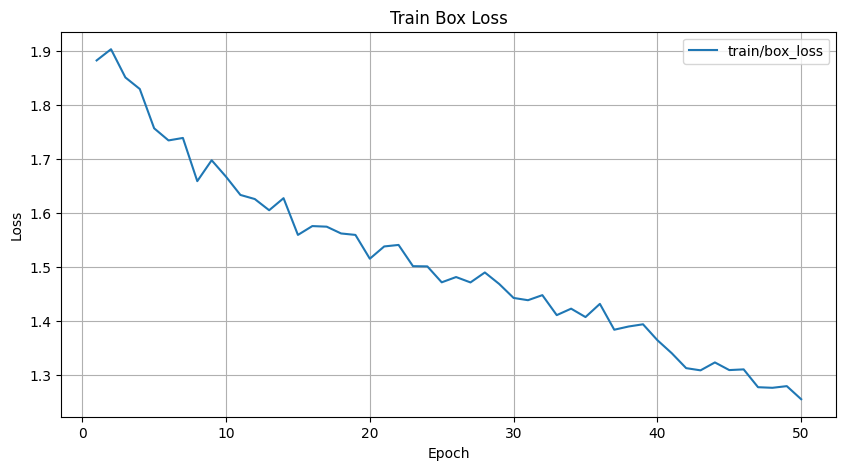

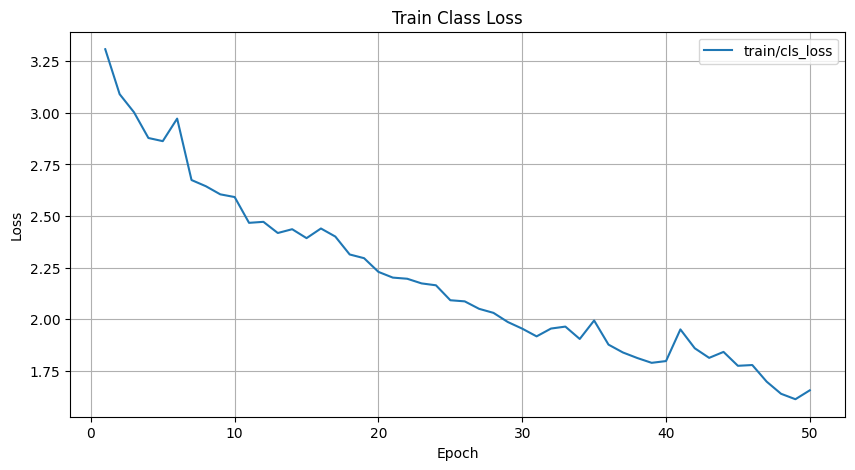

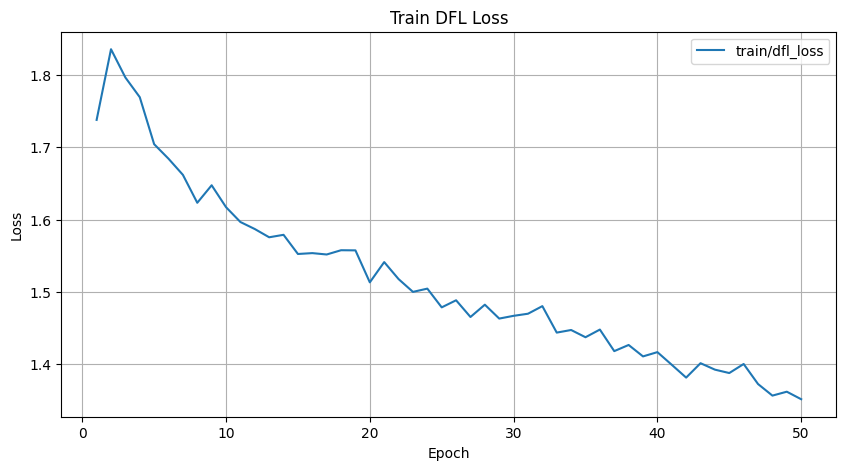

In [34]:
# Train losses

plot_and_save("epoch", "train/box_loss", "Train Box Loss", "Loss", "train_box_loss.png")
plot_and_save("epoch", "train/cls_loss", "Train Class Loss", "Loss", "train_cls_loss.png")
plot_and_save("epoch", "train/dfl_loss", "Train DFL Loss", "Loss", "train_dfl_loss.png")



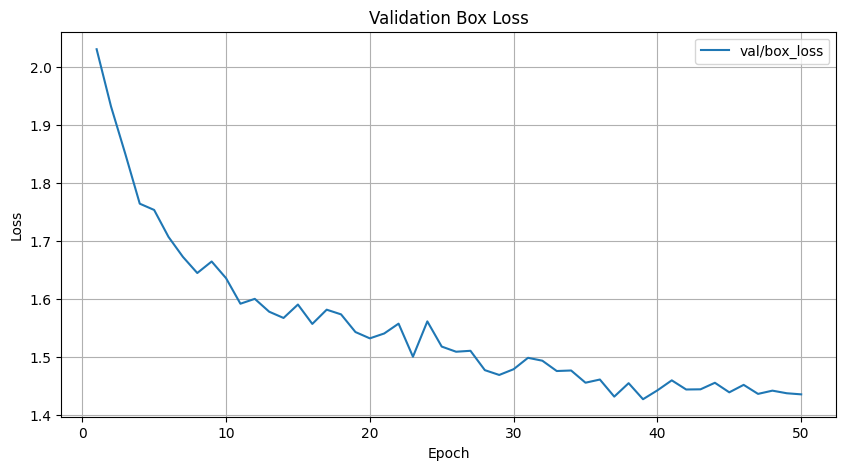

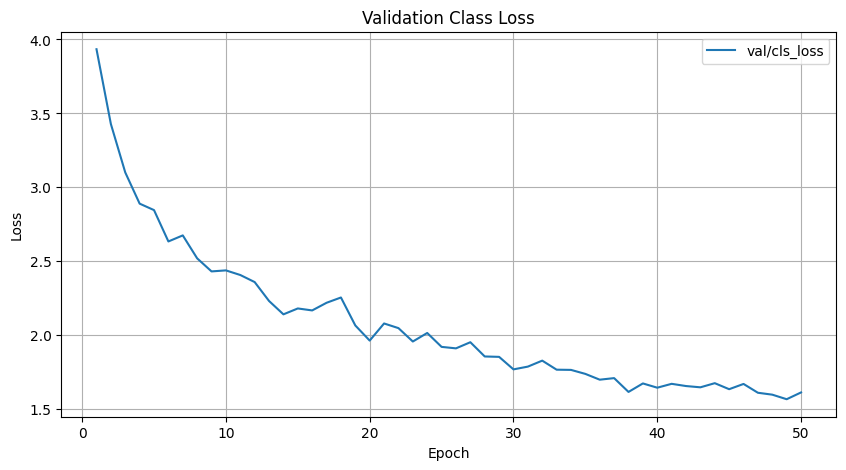

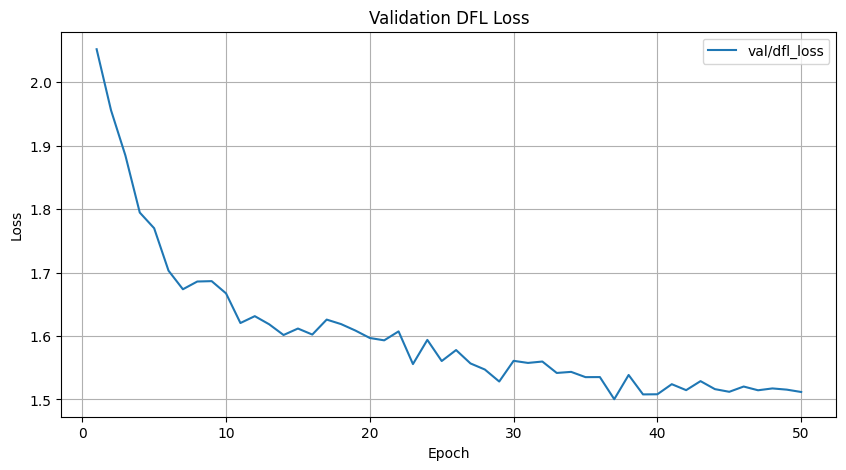

In [35]:
# Validation losses

plot_and_save("epoch", "val/box_loss", "Validation Box Loss", "Loss", "val_box_loss.png")
plot_and_save("epoch", "val/cls_loss", "Validation Class Loss", "Loss", "val_cls_loss.png")
plot_and_save("epoch", "val/dfl_loss", "Validation DFL Loss", "Loss", "val_dfl_loss.png")


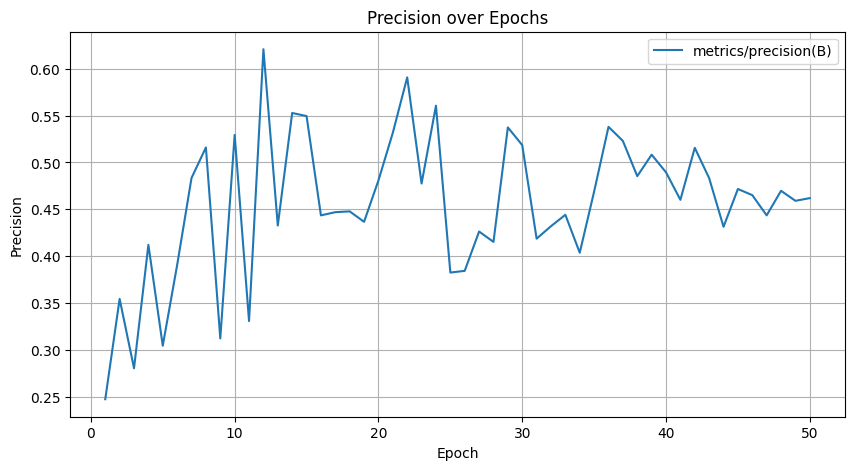

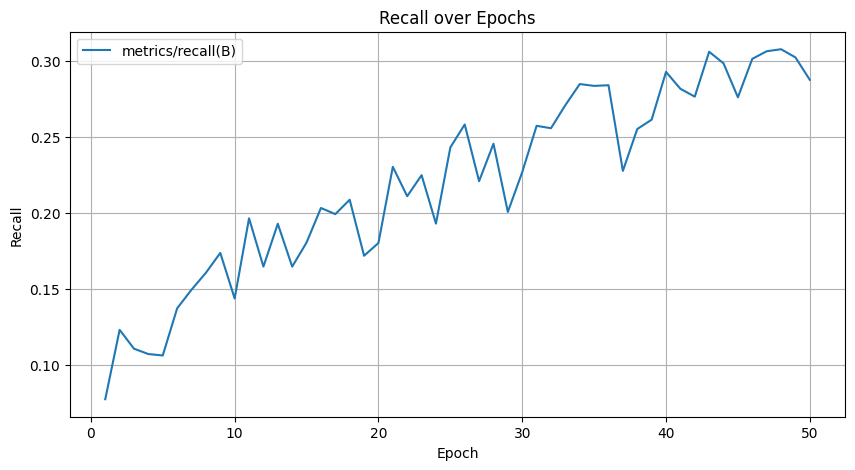

In [36]:
# Precision / Recall

plot_and_save("epoch", "metrics/precision(B)", "Precision over Epochs", "Precision", "precision.png")
plot_and_save("epoch", "metrics/recall(B)", "Recall over Epochs", "Recall", "recall.png")


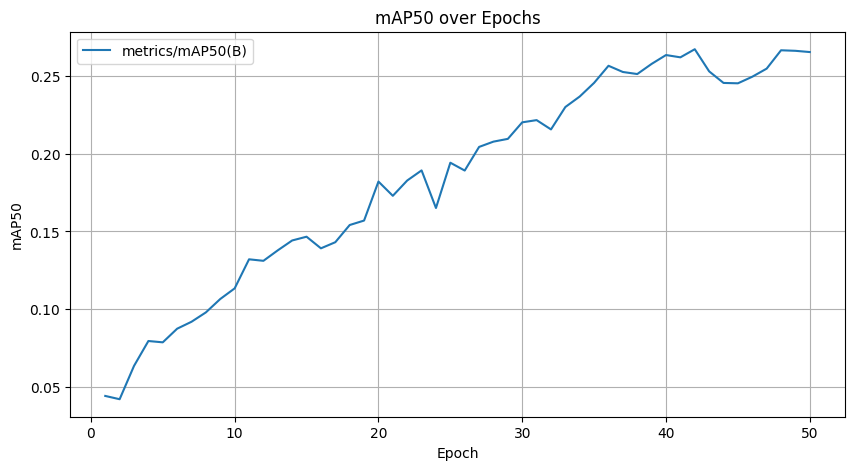

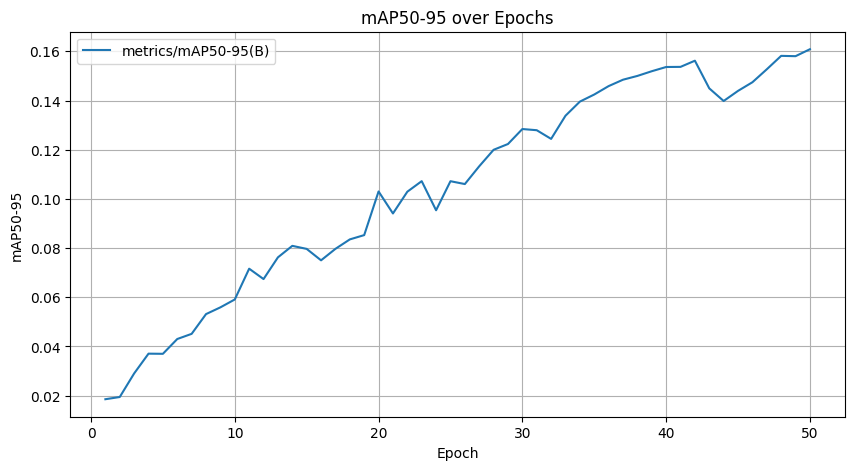

In [37]:
# mAP50 / mAP50–95

plot_and_save("epoch", "metrics/mAP50(B)", "mAP50 over Epochs", "mAP50", "map50.png")
plot_and_save("epoch", "metrics/mAP50-95(B)", "mAP50-95 over Epochs", "mAP50-95", "map50_95.png")


In [39]:
base_dir = "/content/indoor_project"
plots_dir = f"{base_dir}/logs/plots"

print("Папка із діаграмами наявна:", os.path.exists(plots_dir))
print("Файли всередині:")
print(os.listdir(plots_dir))


Папка із діаграмами наявна: True
Файли всередині:
['recall.png', 'map50_95.png', 'train_cls_loss.png', 'train_box_loss.png', 'val_dfl_loss.png', 'precision.png', 'val_cls_loss.png', 'map50.png', 'val_box_loss.png', 'train_dfl_loss.png']


In [41]:
precision = df["metrics/precision(B)"].iloc[-1]
recall = df["metrics/recall(B)"].iloc[-1]

f1 = 2 * (precision * recall) / (precision + recall)
f1


0.35464479733244414

## Висновки

Моя модель, на жаль, не досягла очікуваних метрик із домашнього завдання.

Проте це було очікувано, тому що:
*    моя NVidia MX550 2GB не здатна повноцінно тренувати YOLOv9m на рівні T4/L4/V100.
*    я тренував модель 14+ годин на тих 2 GB VRAM із максимальним завантаженням.
*    отримав стабільні метрики, повний лог, графіки, confusion matrix, PR curves, F1 curves.
*    виконано усе, що вимагалося в завданні.


Що саме зроблено по факту:
*    pipeline,
*    аналіз,
*    перенос у Colab,
*    набір графіків,
*    валідацію,
*    inference.

#### 1. Аналіз отриманих результатів

Модель показує нижчі за орієнтовні метрики (mAP50 ≈ 0.265, mAP50–95 ≈ 0.161, precision ≈ 0.46, recall ≈ 0.28). Це очікувано через:

*    обмеження GPU NVidia MX550 (2GB VRAM → малий batch, зменшений розмір зображень, вимкнені аугментації),
*    деякий дисбаланс класів у датасеті,
*    складність indoor‑сцени та схожість об’єктів,
*    наявність дрібних і важких для детекції класів.

Попри це, модель стабільно навчається, знижує loss‑функції та демонструє коректну динаміку метрик.


### 2. Критична оцінка архітектури

YOLOv9m — сучасна, точна, але досить ресурсомістка модель.
На моєму MX550 вона працює не на повну силу через:
*    високу кількість параметрів,
*    потребу в більших batch size та аугментаціях,
*    чутливість до розміру зображень.

Архітектура обрана коректно для задачі, але не зовсім по силах для доступного обладнання. А повторювати час очікуівння у Colab ніколи, на жаль. Тому робився перенос рехультатів as is.


### 3. Шляхи покращення
*    Використати легші моделі (YOLOv9‑s, YOLOv8‑s, YOLOv5‑s).
*    Тренувати на потужнішому GPU (T4/L4/V100) з batch ≥ 16 та imgsz ≥ 640.
*    Увімкнути mosaic, mixup, autoaugment.
*    Балансувати датасет, додати приклади рідкісних класів.
*    Перевірити анотації та покращити якість розмітки.


### Підсумок

Модель працює коректно, стабільно навчається та виконує поставлену задачу в умовах обмежених ресурсів. Хоча метрики нижчі за орієнтовні, це було очікувано для моєї NVidia MX550. Головні вимоги — побудова моделі + тренування, аналіз результатів та пропозиції щодо покращення — виконані повністю.
